#### Graph API

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [5]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)
graph_builder

In [7]:
import os 
from dotenv import load_dotenv
load_dotenv()


True

In [12]:
from langchain_openai import ChatOpenAI
from langchain.chat_models import init_chat_model

llm=ChatOpenAI(model="gpt-3.5-turbo")
llm


ChatOpenAI(output_version=None, profile={'name': 'GPT-3.5-turbo', 'release_date': '2023-03-01', 'last_updated': '2023-11-06', 'open_weights': False, 'max_input_tokens': 16385, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': False, 'structured_output': False, 'attachment': False, 'temperature': True, 'image_url_inputs': False, 'pdf_inputs': False, 'pdf_tool_message': False, 'image_tool_message': False, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x11800d040>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x1183124b0>, root_client=<openai.OpenAI object at 0x10a421010>, root_async_client=<openai.AsyncOpenAI object at 0x118311a00>, model_kwargs={}, openai_api_key=SecretStr('**********'), openai

In [13]:
llm=init_chat_model("gpt-3.5-turbo")
llm

ChatOpenAI(output_version=None, profile={'name': 'GPT-3.5-turbo', 'release_date': '2023-03-01', 'last_updated': '2023-11-06', 'open_weights': False, 'max_input_tokens': 16385, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': False, 'structured_output': False, 'attachment': False, 'temperature': True, 'image_url_inputs': False, 'pdf_inputs': False, 'pdf_tool_message': False, 'image_tool_message': False, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x11834c140>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11818c620>, root_client=<openai.OpenAI object at 0x11818f0b0>, root_async_client=<openai.AsyncOpenAI object at 0x11834ec90>, model_kwargs={}, openai_api_key=SecretStr('**********'), openai

In [14]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [19]:
graph_builder = StateGraph(State)


graph_builder.add_node("llmchatbot", chatbot)

graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph = graph_builder.compile()


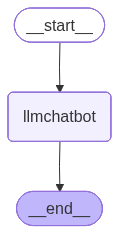

In [21]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

In [31]:
response = graph.invoke({"messages": "Hello, how are you?"})
response["messages"]

[HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='5046e232-87ff-44e0-a537-193d7ae595de'),
 AIMessage(content="Hello! I'm just a computer program, so I don't have feelings, but I'm here to help you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 13, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DetxTdDHnsoKWXj0oyBY4opLJ2XTS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e1f3d-aa96-7272-a99f-31d4a3a24e55-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 31, 'total_tokens': 44, 'input

In [30]:
response["messages"][0].content

'Hello, how are you?'

In [36]:
for event in graph.stream({"messages": "Hello, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm just a computer program, so I don't have feelings, but I'm here to help you. How can I assist you today?


In [37]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3)
tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.britannica.com/place/France',
   'title': 'France | History, Maps, Flag, Population, Cities, Capital, & Facts',
   'content': 'The capital and by far the most important city of France is Paris, one of the world’s preeminent cultural and commercial centres. A majestic city known as the _ville lumière_, or “city of light,” Paris has often been remade, most famously in the mid-19th century under the command of Georges-Eugène, Baron Haussman, who was committed to Napoleon III’s vision of a modern city free of the choleric swamps and congested alleys of old, with broad avenues and a regular plan. Paris is now a sprawling metropolis, one of Europe’s largest conurbations, but its historic heart can still be traversed in an evening’s walk. Confident that their city stood at the very centre of the world, Parisians were once given to referring to their count

In [39]:
def multiply(a: int, b: int) -> int:
    """
    Multiply two integers and return the result integer

    Args:
        a (int): The first integer to multiply
        b (int): The second integer to multiply

    Returns:
        int: The result of multiplying a and b
    """
    return a * b

In [40]:
tools = [tool, multiply]

In [41]:
llm_with_tools = llm.bind_tools(tools)

llm_with_tools

_ChatModelBinding(bound=ChatOpenAI(output_version=None, profile={'name': 'GPT-3.5-turbo', 'release_date': '2023-03-01', 'last_updated': '2023-11-06', 'open_weights': False, 'max_input_tokens': 16385, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': False, 'structured_output': False, 'attachment': False, 'temperature': True, 'image_url_inputs': False, 'pdf_inputs': False, 'pdf_tool_message': False, 'image_tool_message': False, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x11834c140>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11818c620>, root_client=<openai.OpenAI object at 0x11818f0b0>, root_async_client=<openai.AsyncOpenAI object at 0x11834ec90>, model_kwargs={}, openai_api_key=SecretS

In [55]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges("tool_calling_llm", tools_condition)
graph_builder.add_edge("tools", "tool_calling_llm")

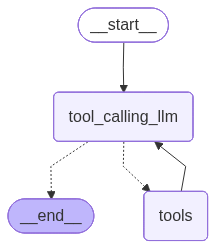

In [56]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [57]:
graph.invoke({"messages": "What is the capital of Switzerland?"})

{'messages': [HumanMessage(content='What is the capital of Switzerland?', additional_kwargs={}, response_metadata={}, id='10215466-5ece-44fd-8d77-fe22819614b5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1300, 'total_tokens': 1323, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DfH61s9cOAuEx1AKDgcTd0YxY0Thr', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e248a-c84f-7310-829e-a6c24e519525-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Capital of Switzerland', 'search_depth': 'basic'}, 'id': 'call_MpvtZvHzMbaVRe8Goq2iqxH3', 'type': 'tool_call'}], invalid_tool_calls=[], usa